In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/telco_churn.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [4]:
tc = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges:", tc.isna().sum())
df.loc[tc.isna(), ["tenure", "MonthlyCharges", "TotalCharges"]]

Blank TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


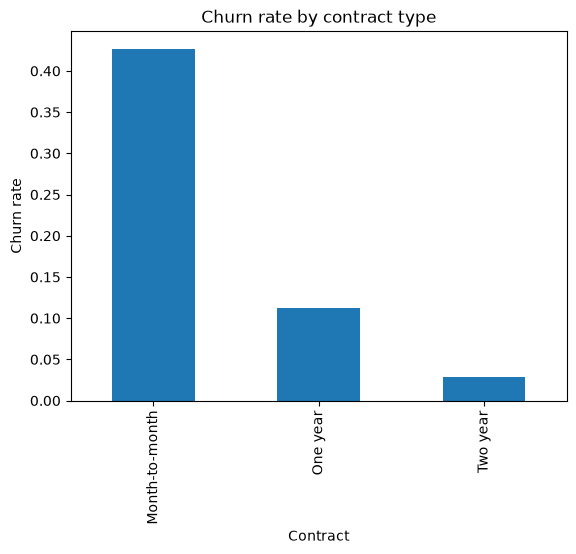

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn_flag, dtype: float64

In [5]:
churn_rate = df.assign(churn_flag=(df["Churn"] == "Yes").astype(int)) \
               .groupby("Contract")["churn_flag"].mean().sort_values(ascending=False)
churn_rate.plot(kind="bar", title="Churn rate by contract type")
plt.ylabel("Churn rate")
plt.show()
churn_rate

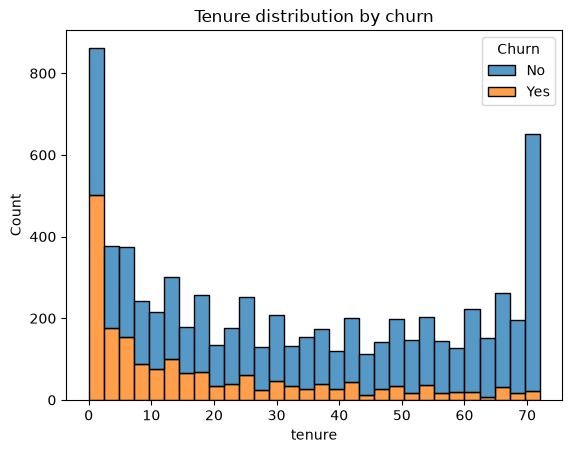

In [6]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure distribution by churn")
plt.show()

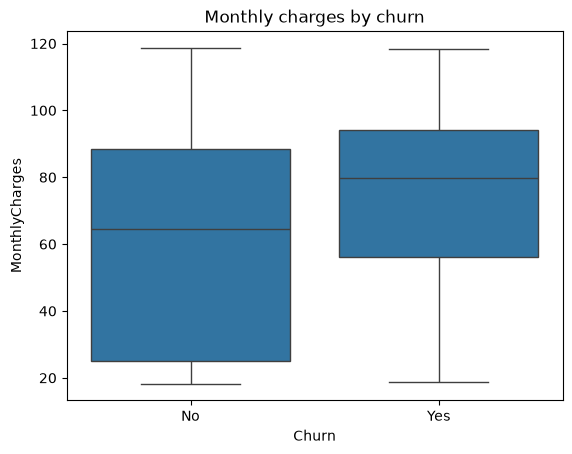

In [7]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges by churn")
plt.show()

## What I found

**The target is imbalanced.** Roughly 26.5% of customers churned, so a model that just predicts "No" every time would already hit ~73% accuracy while catching zero churners. That's why I'm using PR-AUC, recall and F1 instead of accuracy, and adding class weights during training.

**TotalCharges needed fixing.** It loaded as text, not a number. When I converted it, 11 rows came back blank, and every one of them has tenure = 0. These are brand-new customers who haven't been billed yet, so the right value is 0, not the median. I'll fill these with 0 during cleaning.

**Contract type is the clearest signal.** Month-to-month customers churn at about 43%, compared with 11% on one-year contracts and under 3% on two-year contracts. Customers without a commitment are far more likely to leave.

**Most churn happens early.** The tenure chart shows churners heavily concentrated in the first few months (in the first bin, more than half the customers left). After a couple of years, churn becomes rare, and customers around 70 months almost never leave.

**Churners pay more each month.** Their median monthly charge is around 80, compared with about 65 for customers who stayed. Higher bills on flexible contracts look like a risky combination.

**What this means for modelling:** contract, tenure and monthly charges should be strong predictors. Because the classes are imbalanced, I'll split the data with stratification, use class weighting, and judge models mainly on PR-AUC.